In [1]:
from transformers import BertModel, AutoTokenizer
from datasets import load_dataset
import torch
import gensim.downloader
import pandas as pd
import spacy
from collections import defaultdict
import random
import json
import nltk
from nltk.corpus import wordnet as wn
from collections import Counter
from itertools import combinations
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
def load_data(path):
    dataset = load_dataset("wikitext", "wikitext-103-v1", split="train")

    df = pd.read_csv(path, 
                sep="\t", 
                names=["lemma", "forms", "fam", "transf"])
    return dataset, df

In [3]:
def clean_dataset(dataset):
    content = []
    for line in dataset["text"]:
        line = line.strip().lower()
        if line and not line.startswith("=") and len(line.split()) > 4:
            content.append(line)
    return content

In [4]:
def get_target_words(df, glove_voc):
    target = {
            word.strip().lower()
            for form_list in df["forms"].str.split(",")
            for word in form_list
            if word.strip().lower() in glove_voc
    }
    return target

In [5]:
def get_matched_sent(content, target, json_path=None, filename="sent_df"):
    if json_path:
        return pd.read_json(json_path)

    nlp = spacy.blank("en")
    nlp.add_pipe("sentencizer")
    
    matched = defaultdict(set)

    for doc in nlp.pipe(content, batch_size=2048, n_process=2):
        for sent in doc.sents:
            if len(sent) > 40:
                continue

            sent_text = sent.text
            tokens = {token.text for token in sent}

            for word in target.intersection(tokens):
                matched[word].add(sent_text)

    def tag_word(sents):
        n = len(sents)
        if n >= 50:
            return "sampled"
        elif n >= 10:
            return "low_freq"
        return "excluded"

    def sample_sents(sents):
        sents = list(sents)
        n = len(sents)
        if n >= 50:
            return random.sample(sents, 50)
        return sents

    random.seed(42)
    sent_df = pd.DataFrame(matched.items(),
                            columns=["word", "sents"])

    sent_df["tag"] = sent_df["sents"].apply(tag_word)
    sent_df["sents"] = sent_df["sents"].apply(sample_sents)

    sent_df.to_json(f"{filename}.json")
    print(f"{filename}.json created")
    return sent_df

In [8]:
dataset, df = load_data("/home/onyxia/work/morph_families.tsv")
glove = gensim.downloader.load("glove-wiki-gigaword-50")
glove_voc = set(glove.key_to_index.keys())


print("content..")
content = clean_dataset(dataset)
del dataset

print("target..")
target = get_target_words(df, glove_voc)
del df

print("matched..")
sent_df = get_matched_sent(content, target, json_path="sent_df_init.json")

content..
target..
matched..


In [ ]:
sent_df.sample()

In [ ]:
def get_synonyms():
    print("get synonyms..")
    synonyms = set()
    for synset in wn.all_synsets():
        lemmas = [l.name().lower().replace("_", " ") for l in synset.lemmas()]
        for l1, l2 in combinations(lemmas, 2):
            res = tuple(sorted((l1, l2)))
            synonyms.add(res)

    return list(synonyms)


def get_antonyms():
    print("get antonyms..")
    antonyms = set()
    for synset in wn.all_synsets():
        for lemma in synset.lemmas():
            word = lemma.name().lower().replace("_", " ")
            for ant in lemma.antonyms():
                word_ant = ant.name().lower().replace("_", " ")
                res = tuple(sorted((word, word_ant)))
                antonyms.add(res)

    return list(antonyms)


def filter_word(pair_set, glove_voc, word_counts, filename):
    print("filter words..")
    random.seed(42)
    filtered = []
    
    for l1, l2 in pair_set:
        if l1 in glove_voc and l2 in glove_voc:
            if word_counts[l1] >= 10 and word_counts[l2] >= 10:
                filtered.append((l1, l2))

    if len(filtered) > 200:
        filtered = random.sample(filtered, 200)
    else:
        print(f"{len(filtered)} pairs found")
    
    with open(f"/home/onyxia/work/filtered_{filename}.json", "w") as f:
        json.dump(filtered, f)
        
    return list(filtered)


nltk.download("wordnet")
word_counts = Counter()
for sentence in content:
    word_counts.update(sentence.split())

filtered_synonyms = filter_word(get_synonyms(), glove_voc, word_counts, filename="synonyms")
filtered_antonyms = filter_word(get_antonyms(), glove_voc, word_counts, filename="antonyms")

In [ ]:
syn_anto = set()
for l1, l2 in filtered_synonyms + filtered_antonyms:
    syn_anto.add(l1)
    syn_anto.add(l2)

syn_ant_sent = get_matched_sent(content, syn_anto)
corpus = pd.concat([sent_df, syn_ant_sent], ignore_index=True)
corpus = corpus.drop_duplicates(subset="word").reset_index(drop=True)

corpus.to_json("/home/onyxia/work/corpus.json")

In [15]:
with open("/home/onyxia/work/filtered_synonyms.json", "r") as f:
    synonyms = json.load(f)

with open("/home/onyxia/work/filtered_antonyms.json", "r") as f:
    antonyms = json.load(f)

corpus = pd.read_json("/home/onyxia/work/corpus.json")

In [10]:
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

CUDA: True
GPU: Tesla T4


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
bert = BertModel.from_pretrained("bert-base-cased", output_hidden_states=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert.to(device)
bert.eval() # to remove dropout (seen in DL class)

def get_target_emb(sentence, target, layer):
    # gets an unique target embedding
    encoding = tokenizer(sentence, return_tensors="pt")

    word_ids = encoding.word_ids()
    # word_ids = [None, 0, 1, 2, 3, 3, 3, .., None]

    unique_ids = set(i for i in word_ids if i is not None)

    # finds the id of the target word in word_ids
    target_id = None
    for identifier in unique_ids: 
        start, end = encoding.word_to_chars(identifier)
        if sentence[start:end] == target:
            target_id = identifier
            break
    
    if target_id is None:
        return None
        
    # gets all tokens composing the target word
    target_ids = [idx for idx, identifier in enumerate(word_ids)\
                    if identifier == target_id]
    
    with torch.no_grad():
        output = bert(encoding["input_ids"].to(device))

    hidden_states = output.hidden_states
    return hidden_states[layer][0][target_ids].mean(dim=0)
    
appelle_12 = get_target_emb("je m'appelle axel", "appelle", layer=12)
print(appelle_12)
print(appelle_12.size())

In [ ]:
# AI-helped part to solve how to
# save my embeddings and to know where
# to start again if there was a crash,
# as datalab stops often after one hour of service
# UPDATE: It took 20min with a T4, I gave up too fast on this one. 

for layer in [1, 6, 12]:
    print(f"layer {layer}..")
    
    checkpoint_path = f"/home/onyxia/work/embeddings_layer{layer}.json"
    try:
        with open(checkpoint_path, "r") as f:
            layer_embeddings = json.load(f)
        print(f"  resumed from checkpoint: {len(layer_embeddings)}")
    except FileNotFoundError:
        layer_embeddings = {}

    for _, row in tqdm(corpus.iterrows(), total=len(corpus)):
        word = row["word"]
        
        if word in layer_embeddings:
            continue
            
        sentences = row["sents"]
        embs = []
        for sent in sentences:
            emb = get_target_emb(sent, word, layer)
            if emb is not None:
                embs.append(emb)
        
        if embs:
            # I choose to get the mean contextual embeddings to
            # compare with static embeddings of glove
            layer_embeddings[word] = torch.stack(embs).mean(dim=0).cpu().tolist()

    with open(checkpoint_path, "w") as f:
        json.dump(layer_embeddings, f)
    print(f"  layer {layer} done: {len(layer_embeddings)} words")

try:
    with open("/home/onyxia/work/embeddings_glove.json", "r") as f:
        glove_embeddings = json.load(f)
except FileNotFoundError:
    glove_embeddings = {word: glove[word].tolist() 
                        for word in corpus["word"] if word in glove_voc}
    with open("/home/onyxia/work/embeddings_glove.json", "w") as f:
        json.dump(glove_embeddings, f)

100%|██████████| 938/938 [06:50<00:00,  2.29it/s]


  layer 1 done: 938 words
layer 6..


100%|██████████| 938/938 [06:47<00:00,  2.30it/s]


  layer 6 done: 938 words
layer 12..


100%|██████████| 938/938 [06:38<00:00,  2.35it/s]


  layer 12 done: 938 words


layer1:
EVR: [0.02723983 0.02162664 0.01605673 0.01518854 0.01339622 0.01266699
 0.01145967 0.01080296 0.01060575 0.01014485], Cumulative variance: 0.149
layer6:
EVR: [0.04767747 0.02970711 0.02823488 0.01920531 0.01810218 0.0178836
 0.01575042 0.01501923 0.01382969 0.01243117], Cumulative variance: 0.218
layer12:
EVR: [0.07677786 0.02964836 0.02540089 0.0229104  0.01930082 0.01642829
 0.01618272 0.01540581 0.01434422 0.01386331], Cumulative variance: 0.250
glove:
EVR: [0.13919092 0.05840788 0.05242213 0.04461478 0.04104496 0.03539921
 0.03473194 0.03304889 0.03048359 0.02821235], Cumulative variance: 0.498


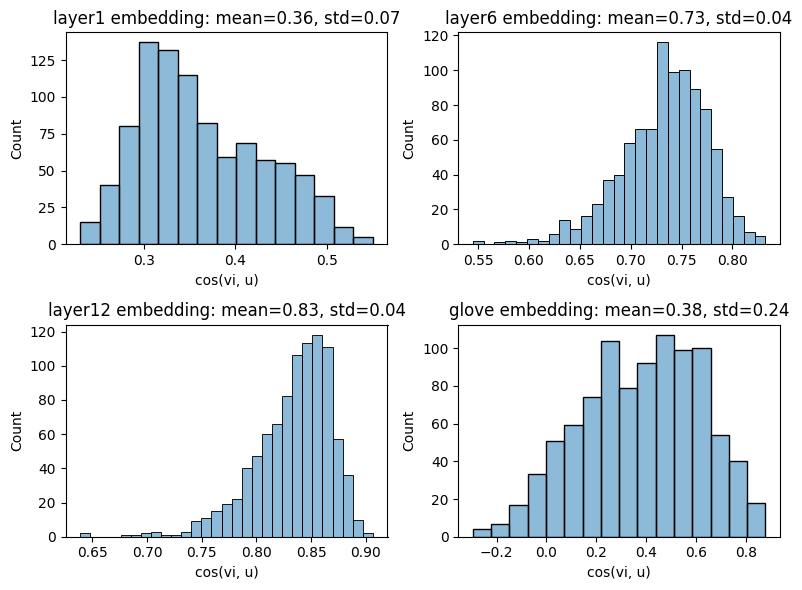

In [5]:
def load_embeddings(path):
    with open (path, "r") as f:
        emb_dict = json.load(f)
        return emb_dict


def convert_to_mat(emb_dict):
    word_list = list(emb_dict.keys())
    wemb_mat = np.array(list(emb_dict.values()))
    return word_list, wemb_mat


def mean_pairwise_cos(wemb_mat):
    similarity = cosine_similarity(wemb_mat)
    pairwise_cos = similarity[np.triu_indices(len(wemb_mat), k=1)]
    # returns [0.1, 0.02, ....] with k=1 to exclude diagonal values

    A1 = pairwise_cos.mean()
    return A1


def cos_to_mean(wemb_mat):
    u = np.mean(wemb_mat, axis=0)
    u = u.reshape(1, -1)
    similarity = cosine_similarity(wemb_mat, u)
    mean = similarity.mean()
    std = np.std(similarity)
    return mean, std, similarity


def pca_dominance(wemb_mat, k=10):
    pca = PCA(n_components=k)
    pca.fit(wemb_mat)
    evr = pca.explained_variance_ratio_
    cum_var = np.cumsum(evr)[-1]
    return evr, cum_var


saved_embs = ["layer1", "layer6", "layer12", "glove"]
res = {}
for emb in saved_embs:
    emb_dict = load_embeddings(f"/home/onyxia/work/embeddings_{emb}.json")
    _, wemb_mat = convert_to_mat(emb_dict)

    mean, std, similarity = cos_to_mean(wemb_mat)
    evr, cum_var = pca_dominance(wemb_mat, k=10)

    res[emb] = {"mean": mean, "std": std, "similarity": similarity}
    print(f"{emb}:\nEVR: {evr}, Cumulative variance: {cum_var:.3f}")

#display results
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
for ax, emb in zip(axes, saved_embs):
    sns.histplot(res[emb]["similarity"], ax=ax)
    ax.set_title(f"{emb} embedding: mean={res[emb]["mean"]:.2f}, std={res[emb]["std"]:.2f}")
    ax.set_xlabel("cos(vi, u)")
    ax.get_legend().remove()
plt.tight_layout()
plt.show()

